In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches


## Import Data ##

In [ ]:
freqTable = pd.read_csv(r"_______", sep="\t", skiprows=1) #frequency table import
freqTable = freqTable.rename(columns = {"#OTU ID" : "FeatureID"})
freqTable.head()

,FeatureID,SRR15018640,SRR15018641,SRR15018642,SRR15018643,SRR15018644,SRR15018645,SRR15018646,SRR15018647,SRR15018648,...,SRR15018731,SRR15018732,SRR15018733,SRR15018734,SRR15018735,SRR15018736,SRR15018737,SRR15018738,SRR15018739,SRR15018740
0,47f27fc06a83dc52f45c8377103c1540,634.0,378.0,1394.0,1282.0,1526.0,1529.0,1237.0,1005.0,698.0,...,1935.0,1056.0,1098.0,2482.0,3241.0,925.0,154.0,288.0,1227.0,2898.0
1,6801b02d1ef62a4cd2ab73f4f39c0bcf,483.0,323.0,1141.0,982.0,1220.0,1123.0,930.0,719.0,490.0,...,1479.0,897.0,970.0,2086.0,2626.0,785.0,95.0,213.0,1063.0,2577.0
2,f204981ee8c56f364d1ff252708c0acc,540.0,354.0,1192.0,1009.0,1152.0,1141.0,890.0,726.0,545.0,...,1510.0,856.0,923.0,2120.0,2570.0,821.0,122.0,194.0,1019.0,2466.0
3,a3cf5ec67c5c5b9d53367f9262e0f05e,516.0,276.0,1130.0,1034.0,1264.0,1251.0,1018.0,779.0,550.0,...,1450.0,888.0,879.0,2026.0,2559.0,819.0,127.0,236.0,970.0,2388.0
4,d4306a4038812836c0f74289076a05ab,358.0,170.0,1029.0,947.0,820.0,717.0,928.0,940.0,527.0,...,1261.0,649.0,607.0,1923.0,3440.0,751.0,0.0,0.0,851.0,2457.0


In [ ]:
tax = pd.read_csv(r"________", sep = "\t", skiprows=1, header=None) #taxonomy table import
tax.columns = ['FeatureID', 'Taxon', 'Confidence']
tax.head()

,FeatureID,Taxon,Confidence
0,47f27fc06a83dc52f45c8377103c1540,d__Bacteria;p__Proteobacteria;c__Alphaproteoba...,0.718252
1,6801b02d1ef62a4cd2ab73f4f39c0bcf,d__Bacteria,0.717686
2,f204981ee8c56f364d1ff252708c0acc,d__Bacteria;p__Proteobacteria;c__Alphaproteoba...,0.704366
3,a3cf5ec67c5c5b9d53367f9262e0f05e,d__Bacteria;p__Proteobacteria;c__Alphaproteoba...,0.767145
4,d4306a4038812836c0f74289076a05ab,d__Bacteria;p__Proteobacteria;c__Alphaproteoba...,0.831097


## Clean from unwanted ##

In [4]:
#Pulling genus and other
unwanted = ["Unassigned", "Mitochondria", "Eukaryota", "uncultured"]

tax["Genus"] = tax["Taxon"].str.extract(r"g__([^;]+)")
tax["Genus"] = tax["Genus"].fillna("Unassigned") #Fills empty with something
merged = freqTable.merge(tax[["FeatureID", "Taxon", "Genus"]], on="FeatureID")

#print(merged[merged.columns[1:102]].sum().sum())

mask = merged["Taxon"].str.contains("|".join(unwanted), case=False, na=False)
filtered = merged[~mask]

genusTable = filtered.groupby("Genus").sum(numeric_only=True)

print(genusTable.sum().sum())
print(genusTable.shape)

1953693.0
(200, 101)


In [5]:
removed = merged[mask]
print(removed[removed.columns[1:102]].sum().sum())
print(removed)

1701215.0
                              FeatureID  SRR15018640  SRR15018641  \
0      47f27fc06a83dc52f45c8377103c1540        634.0        378.0   
2      f204981ee8c56f364d1ff252708c0acc        540.0        354.0   
3      a3cf5ec67c5c5b9d53367f9262e0f05e        516.0        276.0   
4      d4306a4038812836c0f74289076a05ab        358.0        170.0   
5      271d403b81aa28103cdd71a9115d3570        406.0        225.0   
...                                 ...          ...          ...   
27589  0789f45b2e6982bf349b12a387211249          0.0          0.0   
27592  c63cdf7011c759e3fcf05cc24bcc5b80          0.0          0.0   
27593  ccabe12a45d35f509a820fd82b22ede7          0.0          0.0   
27597  a9647a88e5dcc89cda702a53780f9a84          0.0          0.0   
27598  a4f1ad5ffabce2ed5aab74acbfa93559          0.0          0.0   

       SRR15018642  SRR15018643  SRR15018644  SRR15018645  SRR15018646  \
0           1394.0       1282.0       1526.0       1529.0       1237.0   
2           1

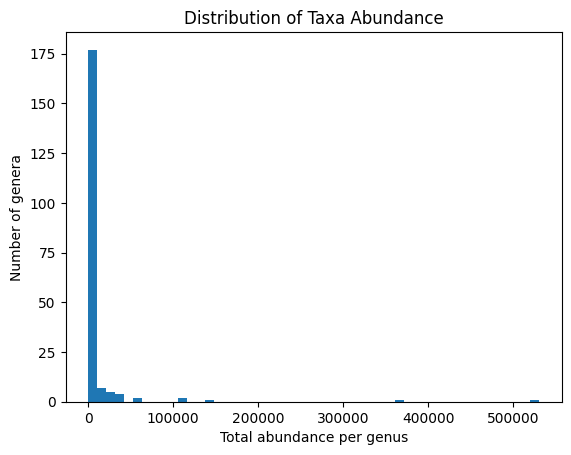

In [6]:
totalCounts = genusTable.sum(axis=1)
plt.figure()
plt.hist(totalCounts, bins=50)
plt.xlabel("Total abundance per genus")
plt.ylabel("Number of genera")
plt.title("Distribution of Taxa Abundance")
plt.show()

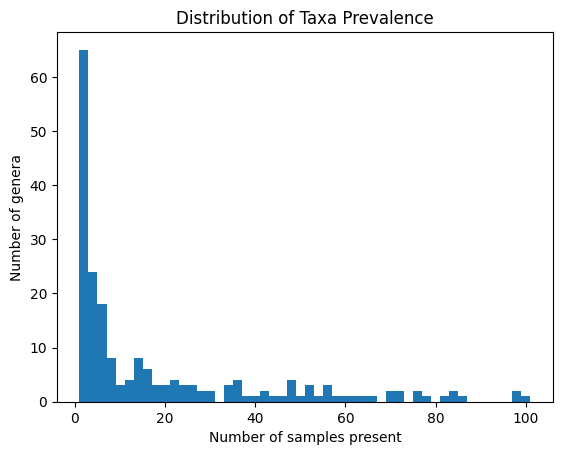

In [7]:
prevalence = (genusTable > 0).sum(axis=1)
plt.figure()
plt.hist(prevalence, bins=50)
plt.xlabel("Number of samples present")
plt.ylabel("Number of genera")
plt.title("Distribution of Taxa Prevalence")
plt.show()

In [8]:
#Filtering next steps?
genusTableFiltered = genusTable[(prevalence >= 3) & (totalCounts >= 20)]
#genusTableFiltered = genusTable[(prevalence >= 3)]
print(genusTableFiltered.shape)

(134, 101)


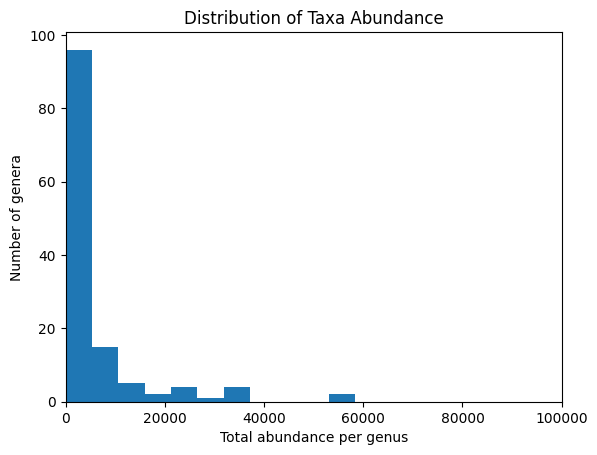

In [9]:
totalCounts = genusTableFiltered.sum(axis=1)
plt.figure()
plt.hist(totalCounts, bins=100)
plt.xlabel("Total abundance per genus")
plt.xlim(0, 100000)
plt.ylabel("Number of genera")
plt.title("Distribution of Taxa Abundance")
plt.show()

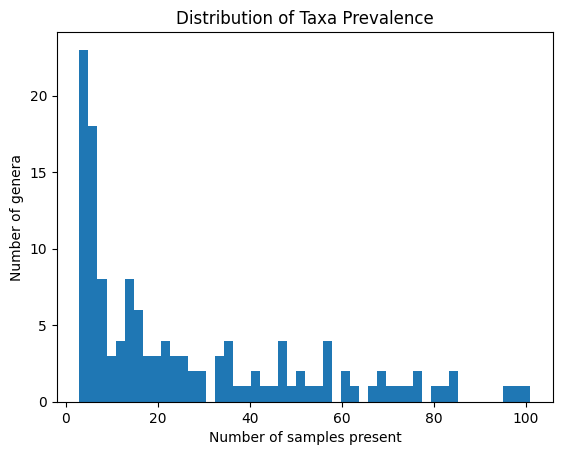

In [10]:
prevalence = (genusTableFiltered > 0).sum(axis=1)
plt.figure()
plt.hist(prevalence, bins=50)
plt.xlabel("Number of samples present")
plt.ylabel("Number of genera")
plt.title("Distribution of Taxa Prevalence")
plt.show()

In [11]:
genusTableFiltered.T.head()

Genus,Actinomyces,Aeromonas,Agathobacter,Akkermansia,Alistipes,Alloprevotella,Anaerococcus,Anaerostipes,Anaerotruncus,Atopobium,...,Unassigned,Veillonella,Victivallis,Woesearchaeales,[Eubacterium]_coprostanoligenes_group,[Eubacterium]_nodatum_group,[Eubacterium]_siraeum_group,[Eubacterium]_xylanophilum_group,[Ruminococcus]_torques_group,vadinBE97
SRR15018640,0.0,0.0,0.0,588.0,290.0,0.0,0.0,0.0,0.0,0.0,...,2829.0,0.0,15.0,622.0,148.0,0.0,0.0,0.0,243.0,0.0
SRR15018641,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1279.0,0.0,0.0,82.0,0.0,0.0,0.0,0.0,12.0,4.0
SRR15018642,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,...,5661.0,0.0,0.0,693.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR15018643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5438.0,0.0,0.0,641.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR15018644,0.0,0.0,0.0,0.0,87.0,80.0,0.0,0.0,0.0,0.0,...,5838.0,0.0,0.0,652.0,7.0,0.0,0.0,0.0,0.0,0.0


## CLR, PCR, and t-SNE ##

In [12]:
# Add pseudocount
data = genusTableFiltered + 1

# Geometric mean per sample
geomMean = np.exp(np.log(data).mean(axis=0))

# CLR transform
clrTable = np.log(data / geomMean)
data.head()

,SRR15018640,SRR15018641,SRR15018642,SRR15018643,SRR15018644,SRR15018645,SRR15018646,SRR15018647,SRR15018648,SRR15018649,...,SRR15018731,SRR15018732,SRR15018733,SRR15018734,SRR15018735,SRR15018736,SRR15018737,SRR15018738,SRR15018739,SRR15018740
Genus,,,,,,,,,,,,,,,,,,,,,
Actinomyces,1.0,1.0,1.0,1.0,1.0,1.0,28.0,143.0,12.0,1.0,...,21.0,39.0,43.0,82.0,1.0,70.0,1.0,1.0,1.0,140.0
Aeromonas,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,114.0,267.0,...,334.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,194.0,15.0
Agathobacter,1.0,1.0,1.0,1.0,1.0,1.0,1.0,36.0,1.0,1.0,...,1.0,1.0,1.0,84.0,1.0,1.0,1.0,44.0,1.0,21.0
Akkermansia,589.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1725.0,470.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Alistipes,291.0,1.0,1.0,1.0,88.0,1.0,1.0,1.0,355.0,121.0,...,56.0,1.0,1.0,19.0,1.0,223.0,59.0,1.0,66.0,1.0


In [ ]:
meta = pd.read_csv(r"_________", sep="\t")
meta = meta.set_index("sample-id")
merged_df = clrTable.T.join(meta, how="inner")

#Binning age into groups
merged_df["AgeGroup"] = pd.cut(
    merged_df["AGE"],
    bins=[0, 40, 60, 80, 100],
    labels=["<40", "40–60", "60–80", "80+"]
)

#Creating recurrence
merged_df["recurrence"] = merged_df["tissue"].apply(
    lambda x: "recurrent" if "recurrent CRC" in x and "non-recurrent" not in x else "non-recurrent"
)

#Creating tissue type column
merged_df["tissue_type"] = merged_df["tissue"].apply(
    lambda x: "CRC tumor" if "tumor" in x else "CRC normal"
)

group_col = "AgeGroup"
meta["AgeGroup"] = merged_df["AgeGroup"]
meta["recurrence"] = merged_df["recurrence"]
meta["tissue_type"] = merged_df["tissue_type"]

In [ ]:
# Prepare data for PCA
taxa_cols = clrTable.T.columns.tolist()
meta_cols = meta.columns.tolist()


X = merged_df[taxa_cols].values
meta = merged_df[meta_cols]

In [15]:
print(f"Taxa columns:     {len(taxa_cols)}")
print(f"Metadata columns: {len(meta_cols)}")
print(f"Total merged cols:{len(merged_df.columns)}")

Taxa columns:     134
Metadata columns: 34
Total merged cols:168


In [16]:
n_components = min(10, X.shape[1])  # compute up to 10 PCs
pca = PCA(n_components=n_components)
pca_coords = pca.fit_transform(X)

explained = pca.explained_variance_ratio_ * 100
print(f"\nVariance explained — PC1: {explained[0]:.1f}%  PC2: {explained[1]:.1f}%")


Variance explained — PC1: 11.7%  PC2: 8.4%


In [17]:
meta.head()

,AGE,Assay Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,Center Name,...,create_date,version,Sample Name,sample_no,sex,SRA Study,tissue,AgeGroup,recurrence,tissue_type
SRR15018640,47,AMPLICON,561,86327066,"Samsung Medical Centers in Seoul\, 06351\, Korea",PRJNA743150,SAMN19999521,Human,57928273,KANGWON NATIONAL UNIVERSITY,...,2021-07-03T07:21:00Z,1,12002841-TN,D_18_06119_DT_TAR_S50,male,SRP326567,recurrent CRC normal,40–60,recurrent,CRC normal
SRR15018641,47,AMPLICON,582,99763498,"Samsung Medical Centers in Seoul\, 06351\, Korea",PRJNA743150,SAMN19999520,Human,66030436,KANGWON NATIONAL UNIVERSITY,...,2021-07-03T07:21:00Z,1,12002841-TT,D_18_06118_DT_TAR_S49,male,SRP326567,recurrent CRC tumor,40–60,recurrent,CRC tumor
SRR15018642,56,AMPLICON,540,105199834,"Samsung Medical Centers in Seoul\, 06351\, Korea",PRJNA743150,SAMN19999519,Human,70804000,KANGWON NATIONAL UNIVERSITY,...,2021-07-03T07:21:00Z,1,12002385-TN,D_18_06117_DT_TAR_S48,male,SRP326567,recurrent CRC normal,40–60,recurrent,CRC normal
SRR15018643,56,AMPLICON,547,103997650,"Samsung Medical Centers in Seoul\, 06351\, Korea",PRJNA743150,SAMN19999518,Human,69723758,KANGWON NATIONAL UNIVERSITY,...,2021-07-03T07:21:00Z,1,12002385-TT,D_18_06116_DT_TAR_S47,male,SRP326567,recurrent CRC tumor,40–60,recurrent,CRC tumor
SRR15018644,75,AMPLICON,546,115153309,"Samsung Medical Centers in Seoul\, 06351\, Korea",PRJNA743150,SAMN19999517,Human,78022731,KANGWON NATIONAL UNIVERSITY,...,2021-07-03T07:21:00Z,1,12001512-TN,D_18_06115_DT_TAR_S46,male,SRP326567,recurrent CRC normal,60–80,recurrent,CRC normal


In [18]:
#Choose which col to color points by
group_col = meta_cols[-2]
print(f"\nColoring by metadata column: '{group_col}'")
print(f"Groups found: {meta[group_col].unique()}")

groups = meta[group_col].astype(str)
unique_groups = sorted(groups.unique())
palette = plt.cm.tab10.colors
color_map = {g: palette[i % len(palette)] for i, g in enumerate(unique_groups)}
colors = [color_map[g] for g in groups]


Coloring by metadata column: 'recurrence'
Groups found: <StringArray>
['recurrent', 'non-recurrent']
Length: 2, dtype: str



Plot saved to: pca_plot.png


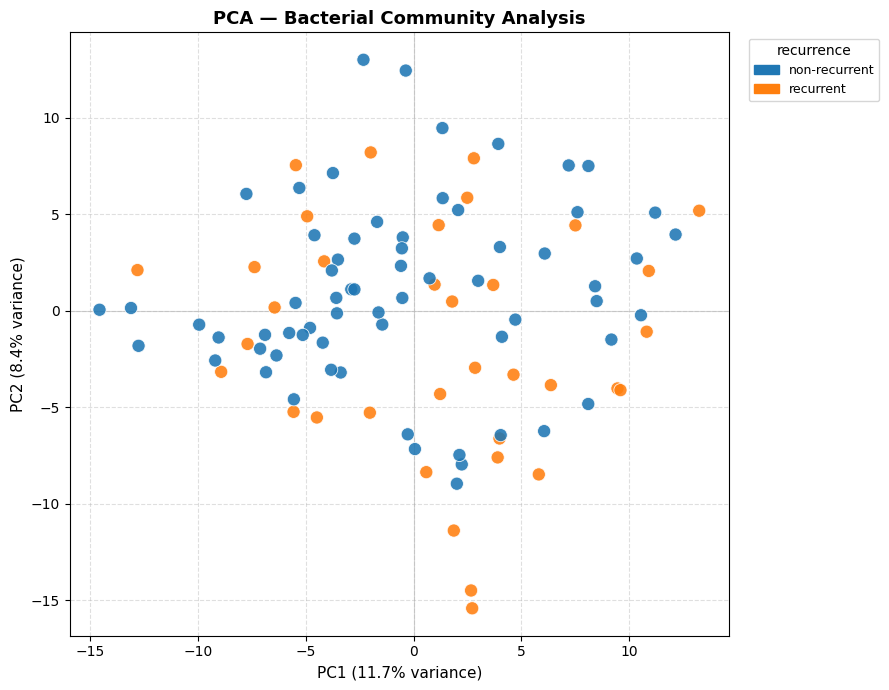

In [19]:
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    pca_coords[:, 0],
    pca_coords[:, 1],
    c=colors,
    s=90,
    edgecolors="white",
    linewidths=0.6,
    alpha=0.88,
    zorder=3,
)

# Label each point with its sample ID
#for i, sample_id in enumerate(merged_df.index):
#    ax.annotate(
#        str(sample_id),
#        xy=(pca_coords[i, 0], pca_coords[i, 1]),
#        xytext=(5, 5),
#        textcoords="offset points",
#        fontsize=7,
#        color="dimgray",
#    )

# Legend
legend_handles = [
    mpatches.Patch(color=color_map[g], label=g) for g in unique_groups
]
ax.legend(
    handles=legend_handles,
    title=group_col,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    fontsize=9,
)

ax.set_xlabel(f"PC1 ({explained[0]:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({explained[1]:.1f}% variance)", fontsize=11)
ax.set_title("PCA — Bacterial Community Analysis", fontsize=13, fontweight="bold")
ax.axhline(0, color="lightgray", lw=0.8, zorder=1)
ax.axvline(0, color="lightgray", lw=0.8, zorder=1)
ax.grid(True, linestyle="--", alpha=0.4, zorder=0)

plt.tight_layout()
output_file = "pca_plot.png"
plt.savefig(output_file, dpi=150, bbox_inches="tight")
print(f"\nPlot saved to: {output_file}")
plt.show()

In [20]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,   
    learning_rate="auto",
    init="pca",
    random_state=42,
)
tsne_coords = tsne.fit_transform(X)

print(f"\nt-SNE KL divergence: {tsne.kl_divergence_:.4f}")


t-SNE KL divergence: 0.3877


Plot saved to: tsne_plot.png


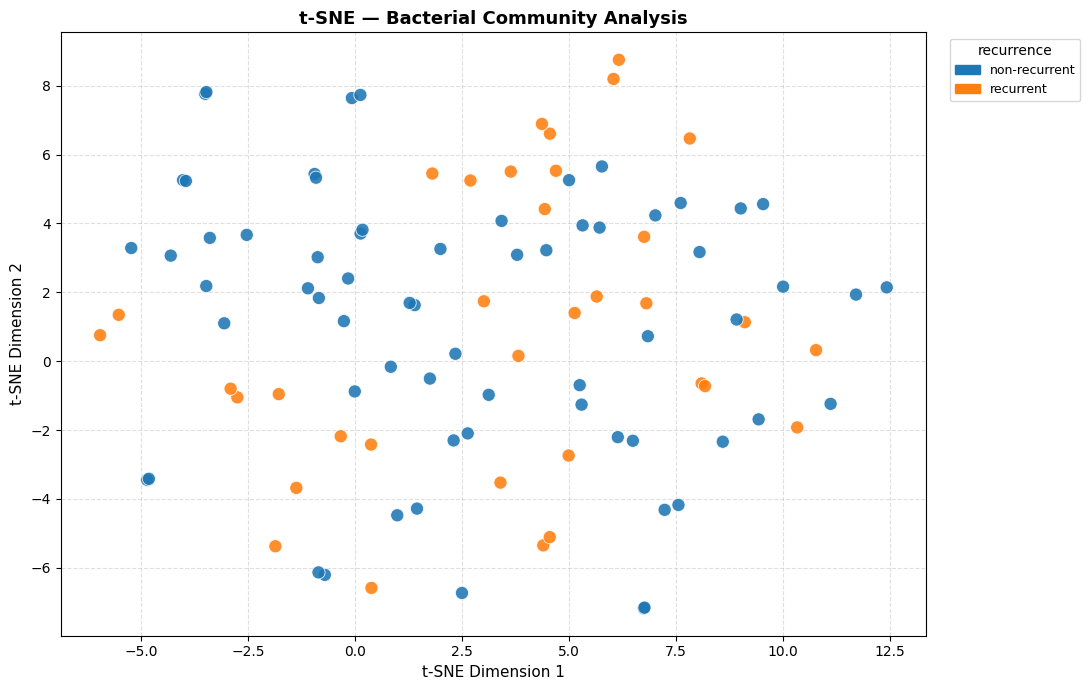

In [21]:
groups = merged_df[group_col].astype(str)
unique_groups = sorted(groups.unique())
palette = plt.cm.tab10.colors
color_map = {g: palette[i % len(palette)] for i, g in enumerate(unique_groups)}
colors = [color_map[g] for g in groups]

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    tsne_coords[:, 0],
    tsne_coords[:, 1],
    c=colors,
    s=90,
    edgecolors="white",
    linewidths=0.6,
    alpha=0.88,
    zorder=3,
)

# Label each point with its sample ID
'''
for i, sample_id in enumerate(merged_df.index):
    ax.annotate(
        str(sample_id),
        xy=(tsne_coords[i, 0], tsne_coords[i, 1]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=7,
        color="dimgray",
    )
'''
# Legend
legend_handles = [
    mpatches.Patch(color=color_map[g], label=g) for g in unique_groups
]
ax.legend(
    handles=legend_handles,
    title=group_col,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    fontsize=9,
)

ax.set_xlabel("t-SNE Dimension 1", fontsize=11)
ax.set_ylabel("t-SNE Dimension 2", fontsize=11)
ax.set_title("t-SNE — Bacterial Community Analysis", fontsize=13, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig("tsne_plot.png", dpi=150, bbox_inches="tight")
print("Plot saved to: tsne_plot.png")
plt.show()

Plot saved to: tsne_plot.png


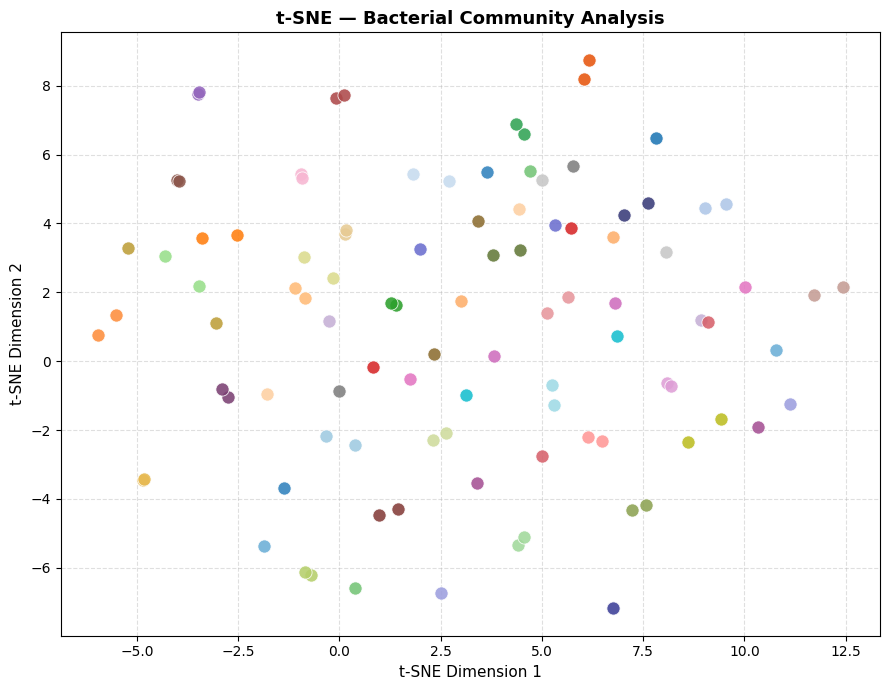

In [ ]:
import matplotlib.markers as mmarkers

# Extract the number prefix from "Sample Name" (e.g., "12-TT" -> "12")
sample_numbers = merged_df["Sample Name"].astype(str).str.extract(r'^(\d+)')[0]
unique_numbers = sorted(sample_numbers.unique(), key=lambda x: int(x))

# --- Expanded palette: use tab20 (20 colors) instead of tab10 (10) ---
#palette = plt.cm.tab20.colors
palette = plt.cm.tab20.colors + plt.cm.tab20b.colors + plt.cm.tab20c.colors 

# --- Distinct markers to pair with colors ---
#marker_list = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'p', 'h',
#               '<', '>', '8', 'H', 'd', '1', '2', '3', '4', '+']

number_color_map = {num: palette[i % len(palette)] for i, num in enumerate(unique_numbers)}
#number_marker_map = {num: marker_list[i % len(marker_list)] for i, num in enumerate(unique_numbers)}

fig, ax = plt.subplots(figsize=(9, 7))

# Plot each patient group separately so each gets its own color + marker
for num in unique_numbers:
    mask = sample_numbers == num
    ax.scatter(
        tsne_coords[mask, 0],
        tsne_coords[mask, 1],
        c=[number_color_map[num]],
        s=90,
        edgecolors="white",
        linewidths=0.6,
        alpha=0.88,
        zorder=3,
        label=f"Patient {num}",
    )

# Label each point with its sample ID
'''
for i, sample_id in enumerate(merged_df.index):
    ax.annotate(
        str(sample_id),
        xy=(tsne_coords[i, 0], tsne_coords[i, 1]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=7,
        color="dimgray",
    )
'''
'''
ax.legend(
    title="Patient",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    fontsize=8,
    ncol=2 if len(unique_numbers) > 15 else 1,
)
'''


ax.set_xlabel("t-SNE Dimension 1", fontsize=11)
ax.set_ylabel("t-SNE Dimension 2", fontsize=11)
ax.set_title("t-SNE — Bacterial Community Analysis", fontsize=13, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig("tsne_plot.png", dpi=150, bbox_inches="tight")
print("Plot saved to: tsne_plot.png")
plt.show()

In [23]:
merged_df.head()

,Actinomyces,Aeromonas,Agathobacter,Akkermansia,Alistipes,Alloprevotella,Anaerococcus,Anaerostipes,Anaerotruncus,Atopobium,...,create_date,version,Sample Name,sample_no,sex,SRA Study,tissue,AgeGroup,recurrence,tissue_type
SRR15018640,-1.286807,-1.286807,-1.286807,5.091620,4.386517,-1.286807,-1.286807,-1.286807,-1.286807,-1.286807,...,2021-07-03T07:21:00Z,1,12002841-TN,D_18_06119_DT_TAR_S50,male,SRP326567,recurrent CRC normal,40–60,recurrent,CRC normal
SRR15018641,-0.395920,-0.395920,-0.395920,-0.395920,-0.395920,-0.395920,-0.395920,-0.395920,-0.395920,-0.395920,...,2021-07-03T07:21:00Z,1,12002841-TT,D_18_06118_DT_TAR_S49,male,SRP326567,recurrent CRC tumor,40–60,recurrent,CRC tumor
SRR15018642,-0.316812,-0.316812,-0.316812,-0.316812,-0.316812,-0.316812,1.880413,-0.316812,-0.316812,-0.316812,...,2021-07-03T07:21:00Z,1,12002385-TN,D_18_06117_DT_TAR_S48,male,SRP326567,recurrent CRC normal,40–60,recurrent,CRC normal
SRR15018643,-0.355418,-0.355418,-0.355418,-0.355418,-0.355418,-0.355418,-0.355418,-0.355418,-0.355418,-0.355418,...,2021-07-03T07:21:00Z,1,12002385-TT,D_18_06116_DT_TAR_S47,male,SRP326567,recurrent CRC tumor,40–60,recurrent,CRC tumor
SRR15018644,-0.857844,-0.857844,-0.857844,-0.857844,3.619493,3.536605,-0.857844,-0.857844,-0.857844,-0.857844,...,2021-07-03T07:21:00Z,1,12001512-TN,D_18_06115_DT_TAR_S46,male,SRP326567,recurrent CRC normal,60–80,recurrent,CRC normal


In [24]:
clrTable = clrTable.T

In [25]:
meta.head(-5)

,AGE,Assay Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,Center Name,...,create_date,version,Sample Name,sample_no,sex,SRA Study,tissue,AgeGroup,recurrence,tissue_type
SRR15018640,47,AMPLICON,561,86327066,"Samsung Medical Centers in Seoul\, 06351\, Korea",PRJNA743150,SAMN19999521,Human,57928273,KANGWON NATIONAL UNIVERSITY,...,2021-07-03T07:21:00Z,1,12002841-TN,D_18_06119_DT_TAR_S50,male,SRP326567,recurrent CRC normal,40–60,recurrent,CRC normal
SRR15018641,47,AMPLICON,582,99763498,"Samsung Medical Centers in Seoul\, 06351\, Korea",PRJNA743150,SAMN19999520,Human,66030436,KANGWON NATIONAL UNIVERSITY,...,2021-07-03T07:21:00Z,1,12002841-TT,D_18_06118_DT_TAR_S49,male,SRP326567,recurrent CRC tumor,40–60,recurrent,CRC tumor
SRR15018642,56,AMPLICON,540,105199834,"Samsung Medical Centers in Seoul\, 06351\, Korea",PRJNA743150,SAMN19999519,Human,70804000,KANGWON NATIONAL UNIVERSITY,...,2021-07-03T07:21:00Z,1,12002385-TN,D_18_06117_DT_TAR_S48,male,SRP326567,recurrent CRC normal,40–60,recurrent,CRC normal
SRR15018643,56,AMPLICON,547,103997650,"Samsung Medical Centers in Seoul\, 06351\, Korea",PRJNA743150,SAMN19999518,Human,69723758,KANGWON NATIONAL UNIVERSITY,...,2021-07-03T07:21:00Z,1,12002385-TT,D_18_06116_DT_TAR_S47,male,SRP326567,recurrent CRC tumor,40–60,recurrent,CRC tumor
SRR15018644,75,AMPLICON,546,115153309,"Samsung Medical Centers in Seoul\, 06351\, Korea",PRJNA743150,SAMN19999517,Human,78022731,KANGWON NATIONAL UNIVERSITY,...,2021-07-03T07:21:00Z,1,12001512-TN,D_18_06115_DT_TAR_S46,male,SRP326567,recurrent CRC normal,60–80,recurrent,CRC normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR15018731,57,AMPLICON,568,100808230,"Samsung Medical Centers in Seoul\, 06351\, Korea",PRJNA743150,SAMN19999438,Human,61281130,KANGWON NATIONAL UNIVERSITY,...,2021-07-03T07:23:00Z,1,11000359-TT,D_18_06036_DT_TAR_S17,male,SRP326567,non-recurrent CRC tumor,40–60,non-recurrent,CRC tumor
SRR15018732,61,AMPLICON,576,73924868,"Samsung Medical Centers in Seoul\, 06351\, Korea",PRJNA743150,SAMN19999437,Human,50538412,KANGWON NATIONAL UNIVERSITY,...,2021-07-03T07:22:00Z,1,11000350-TN,D_18_06035_DT_TAR_S16,male,SRP326567,non-recurrent CRC normal,60–80,non-recurrent,CRC normal
SRR15018733,61,AMPLICON,582,98397179,"Samsung Medical Centers in Seoul\, 06351\, Korea",PRJNA743150,SAMN19999436,Human,61750665,KANGWON NATIONAL UNIVERSITY,...,2021-07-03T07:22:00Z,1,11000350-TT,D_18_06034_DT_TAR_S15,male,SRP326567,non-recurrent CRC tumor,60–80,non-recurrent,CRC tumor
SRR15018734,52,AMPLICON,546,98896676,"Samsung Medical Centers in Seoul\, 06351\, Korea",PRJNA743150,SAMN19999435,Human,60570111,KANGWON NATIONAL UNIVERSITY,...,2021-07-03T07:22:00Z,1,11000288-TN,D_18_06033_DT_TAR_S14,male,SRP326567,non-recurrent CRC normal,40–60,non-recurrent,CRC normal


## Permutation Testing ##

In [ ]:
norm_df = pd.DataFrame(columns=clrTable.columns)
crc_df = pd.DataFrame(columns=clrTable.columns)
# Iterate through samples in clrTable and assign to norm_df or crc_df based on metadata
for srr in clrTable.index:
    if srr not in meta.index:
        continue
    
    sample_name = meta.loc[srr, "Sample Name"]
    sample_num = sample_name.split("-")[0]

    if sample_name.endswith("TN"):
        norm_df.loc[sample_num] = clrTable.loc[srr]
    elif sample_name.endswith("TT"):
        crc_df.loc[sample_num] = clrTable.loc[srr]

# Keep only paired samples (present in both)
shared = norm_df.index.intersection(crc_df.index)
norm_df = norm_df.loc[shared]
crc_df = crc_df.loc[shared]

print(f"Paired samples: {len(shared)}")
print(f"norm_df shape:  {norm_df.shape}")
print(f"crc_df shape:   {crc_df.shape}")

Paired samples: 50
norm_df shape:  (50, 134)
crc_df shape:   (50, 134)


In [ ]:
dot_products = []
# Compute cosine similarity (dot product of normalized vectors) for each pair
for srr in range(len(norm_df.index)):
    g1_vec = norm_df.iloc[srr]
    g1_vec = g1_vec/np.linalg.norm(g1_vec)
    g2_vec = crc_df.iloc[srr]
    g2_vec = g2_vec/np.linalg.norm(g2_vec)

    dot_products.append(np.dot(g1_vec, g2_vec))

mean_dot_product_original = np.mean(dot_products)
print(f"Number of pairs: {len(dot_products)}")
print(f"Mean dot product: {mean_dot_product_original}")

Number of pairs: 50
Mean dot product: 0.7200911069153668


In [ ]:
dot_products = []
means = []
# Permutation test: shuffle norm_df rows and recompute mean dot product 10,000 times
for i in range(10000):
    norm_df_shuffled = norm_df.sample(frac=1)
    dot_products = []
    for srr in range(len(norm_df.index)):
        g1_vec = norm_df_shuffled.iloc[srr]
        g1_vec = g1_vec/np.linalg.norm(g1_vec)
        g2_vec = crc_df.iloc[srr]
        g2_vec = g2_vec/np.linalg.norm(g2_vec)
        dot_products.append(np.dot(g1_vec, g2_vec))

    means.append(np.mean(dot_products))
print(f"Mean dot product: {means}")

Mean dot product: [np.float64(0.46481765024571686), np.float64(0.47374379397983923), np.float64(0.46403501608285114), np.float64(0.46359505324973965), np.float64(0.47318228135314505), np.float64(0.4806963317769673), np.float64(0.4717040664392646), np.float64(0.473886297269284), np.float64(0.46413178928528337), np.float64(0.4588466881570376), np.float64(0.47109764675331367), np.float64(0.45584641148767874), np.float64(0.45650497720587824), np.float64(0.4487289183952851), np.float64(0.46279839628625524), np.float64(0.4625028573207398), np.float64(0.46636818680715075), np.float64(0.45991252429704604), np.float64(0.45840323953103446), np.float64(0.47025643402740086), np.float64(0.4742542792906036), np.float64(0.4837658429409772), np.float64(0.45580549602528947), np.float64(0.4579588062854056), np.float64(0.469512206189), np.float64(0.4649416384579002), np.float64(0.4826806836444372), np.float64(0.4845267703374148), np.float64(0.4674297042015668), np.float64(0.4855990394928481), np.float64(

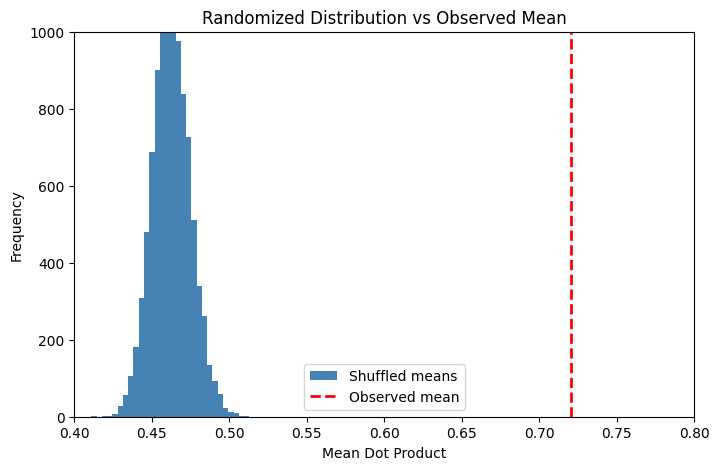

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, color="steelblue", label="Shuffled means")
plt.axvline(x=mean_dot_product_original, color="red", linestyle="--", 
            linewidth=2, label="Observed mean")
plt.xlabel("Mean Dot Product")
plt.ylabel("Frequency")
plt.ylim(0,1000)
plt.xlim(0.4,0.8)
plt.legend()
plt.title("Randomized Distribution vs Observed Mean")
plt.show()

In [51]:
p_value = np.mean(np.abs(means) >= np.abs(mean_dot_product_original))
print(np.mean(means))
print(max(means))
print(f"P-value: {p_value}")

0.46270246108120916
0.5097197918154706
P-value: 0.0


## RF on distance between tumor vs non-tumor samples ##

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

In [31]:
merged_df = clrTable.join(meta[["recurrence"]], how="inner")

print(f"Samples after merge: {len(merged_df)}")
print(f"Class distribution:\n{merged_df['recurrence'].value_counts()}")

Samples after merge: 101
Class distribution:
recurrence
non-recurrent    66
recurrent        35
Name: count, dtype: int64


In [32]:
X = merged_df.drop(columns=["recurrence"]).values
y = merged_df["recurrence"].values

# Encode labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\nClasses: {le.classes_}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded      # preserve class balance in both splits
)

print(f"\nTrain: {len(X_train)} samples | Test: {len(X_test)} samples")




Classes: ['non-recurrent' 'recurrent']

Train: 80 samples | Test: 21 samples


In [33]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",    
    min_samples_leaf=2,     # lower overfitting
    class_weight="balanced",# compensates for any class imbalance
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("\n── Classification Report ──────────────────")
print(classification_report(y_test, y_pred, target_names=le.classes_))


── Classification Report ──────────────────
               precision    recall  f1-score   support

non-recurrent       0.69      0.64      0.67        14
    recurrent       0.38      0.43      0.40         7

     accuracy                           0.57        21
    macro avg       0.53      0.54      0.53        21
 weighted avg       0.59      0.57      0.58        21



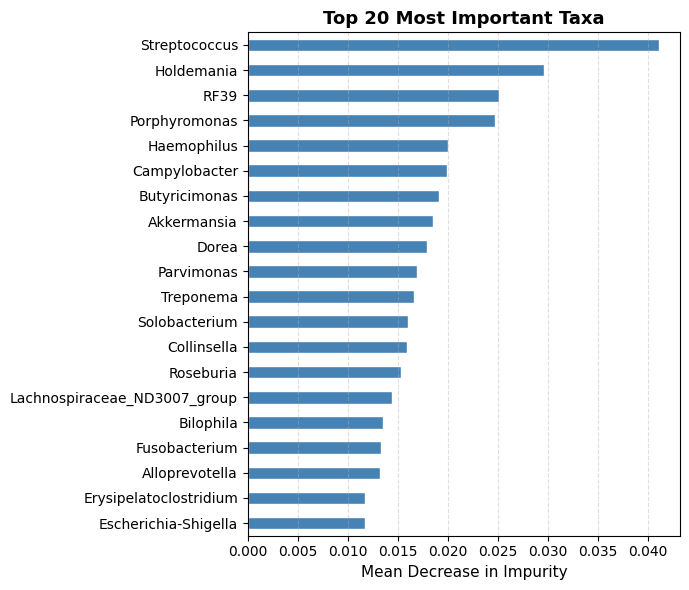

In [34]:
taxa_names = clrTable.columns.tolist()
importances = pd.Series(rf.feature_importances_, index=taxa_names)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
top20.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Mean Decrease in Impurity", fontsize=11)
ax.set_title("Top 20 Most Important Taxa", fontsize=13, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
delta_df = crc_df.subtract(norm_df)
print(f"Shape:        {delta_df.shape}")
print(f"NaN values:   {delta_df.isna().sum().sum()}")  # should be 0 if indices matched
print(f"\nSample of delta values:\n{delta_df.iloc[:3, :5]}")

Shape:        (50, 134)
NaN values:   0

Sample of delta values:
Genus     Actinomyces  Aeromonas  Agathobacter  Akkermansia  Alistipes
12002841     0.890887   0.890887      0.890887    -5.487540  -4.782437
12002385    -0.038606  -0.038606     -0.038606    -0.038606  -0.038606
12001512     0.346017   0.346017      0.346017     0.346017  -4.131320


In [36]:
meta_norm = meta[meta["Sample Name"].str.endswith("TN")].copy()
meta_norm.index = meta_norm["Sample Name"].str.split("-").str[0]

merged_delta = delta_df.join(meta_norm[["recurrence"]], how="inner")

print(f"Samples after merge: {len(merged_delta)}")
print(f"Class distribution:\n{merged_delta['recurrence'].value_counts()}")


X = merged_delta.drop(columns=["recurrence"]).values
y = merged_delta["recurrence"].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\nClasses: {le.classes_}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTrain: {len(X_train)} samples | Test: {len(X_test)} samples")

rf = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)

print("\n── Classification Report ──────────────────")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Samples after merge: 50
Class distribution:
recurrence
non-recurrent    33
recurrent        17
Name: count, dtype: int64

Classes: ['non-recurrent' 'recurrent']

Train: 40 samples | Test: 10 samples

── Classification Report ──────────────────
               precision    recall  f1-score   support

non-recurrent       0.86      0.86      0.86         7
    recurrent       0.67      0.67      0.67         3

     accuracy                           0.80        10
    macro avg       0.76      0.76      0.76        10
 weighted avg       0.80      0.80      0.80        10



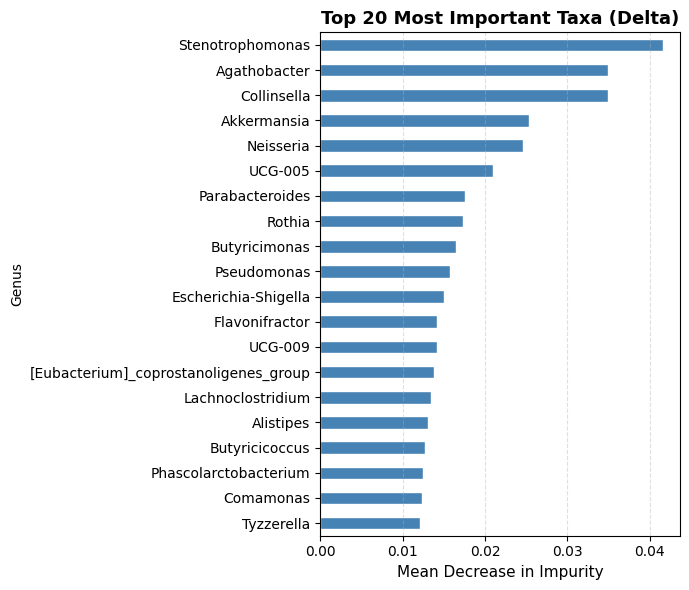

In [37]:
importances = pd.Series(rf.feature_importances_, index=delta_df.columns)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
top20.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Mean Decrease in Impurity", fontsize=11)
ax.set_title("Top 20 Most Important Taxa (Delta)", fontsize=13, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("rf_delta_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
mask = merged_delta["recurrence"] == "recurrent"

merged_delta["Agathobacter"][mask].mean()



np.float64(0.41034820658171656)

In [39]:
mask = merged_delta["recurrence"] == "non-recurrent"

merged_delta["Agathobacter"][mask].mean()
#Make box plot for top groups

np.float64(-0.5927275954626978)

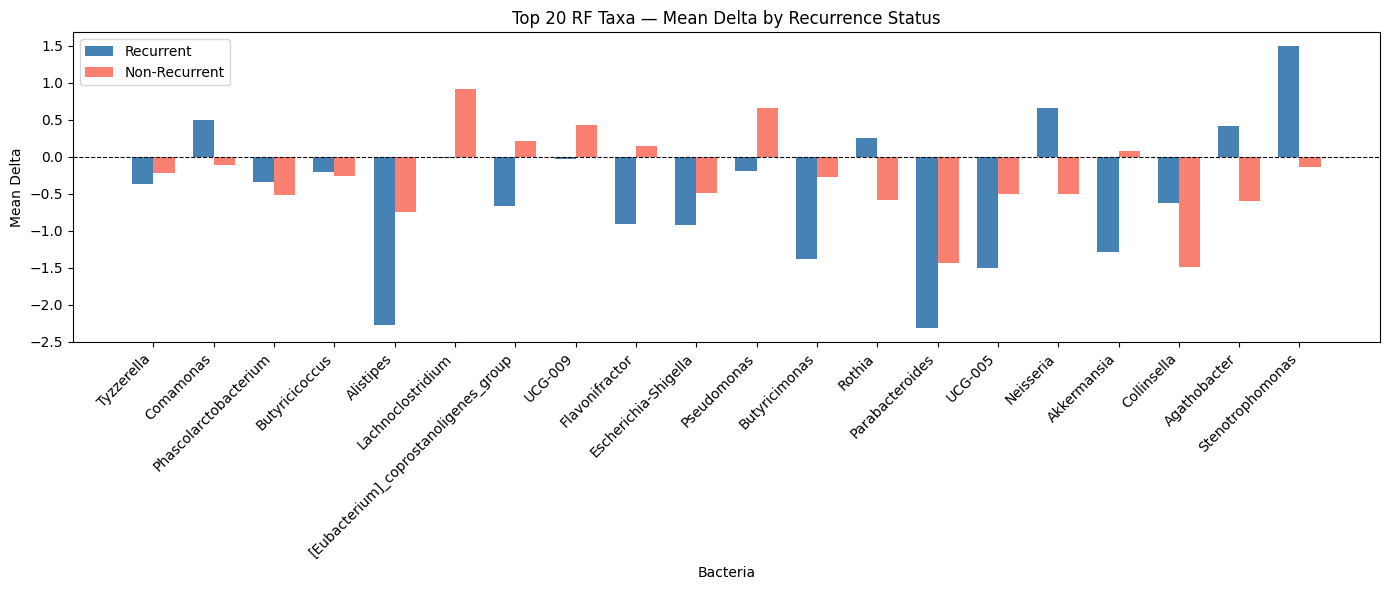

In [40]:
# Get top 20 taxa names from RF importances
top20 = importances.nlargest(20).sort_values()
top20_cols = top20.index.tolist()

# Separate by recurrence
recurrent = merged_delta[merged_delta["recurrence"] == "recurrent"]
non_recurrent = merged_delta[merged_delta["recurrence"] == "non-recurrent"]

# Compute means for top 20 only
summary = pd.DataFrame({
    "recurrent": recurrent[top20_cols].mean(),
    "non-recurrent": non_recurrent[top20_cols].mean()
})

# --- Bar chart ---
x = np.arange(len(top20_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - width/2, summary["recurrent"], width, label="Recurrent", color="steelblue")
ax.bar(x + width/2, summary["non-recurrent"], width, label="Non-Recurrent", color="salmon")

ax.set_xlabel("Bacteria")
ax.set_ylabel("Mean Delta")
ax.set_title("Top 20 RF Taxa — Mean Delta by Recurrence Status")
ax.set_xticks(x)
ax.set_xticklabels(top20_cols, rotation=45, ha="right")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.legend()

plt.tight_layout()
plt.show()

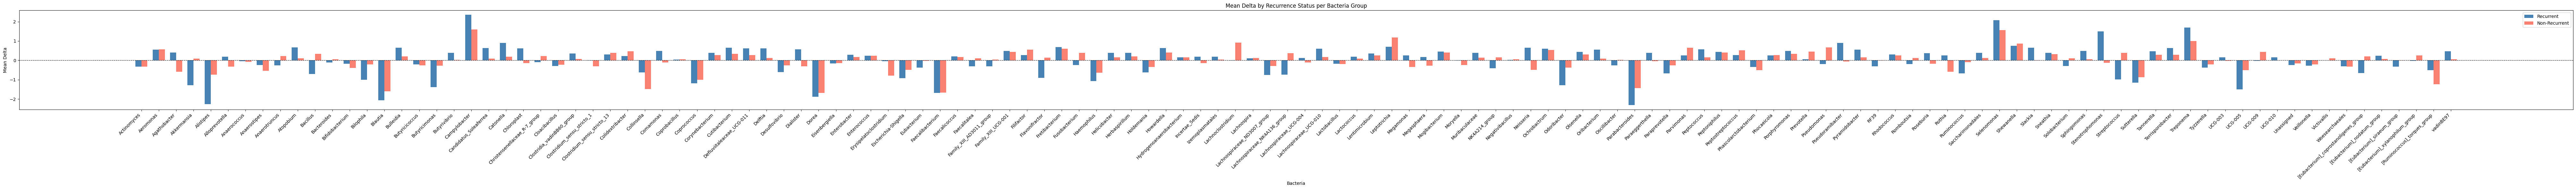

In [41]:
# Separate by recurrence
recurrent = merged_delta[merged_delta["recurrence"] == "recurrent"]
non_recurrent = merged_delta[merged_delta["recurrence"] == "non-recurrent"]

# Get bacteria columns (everything except recurrence)
bacteria_cols = [col for col in merged_delta.columns if col != "recurrence"]

# Compute means for each group
recurrent_means = recurrent[bacteria_cols].mean()
non_recurrent_means = non_recurrent[bacteria_cols].mean()

# Build summary df
summary = pd.DataFrame({
    "recurrent": recurrent_means,
    "non-recurrent": non_recurrent_means
})

# --- Bar chart ---
x = np.arange(len(bacteria_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(max(10, len(bacteria_cols) * 0.6), 6))

bars1 = ax.bar(x - width/2, summary["recurrent"], width, label="Recurrent", color="steelblue")
bars2 = ax.bar(x + width/2, summary["non-recurrent"], width, label="Non-Recurrent", color="salmon")

ax.set_xlabel("Bacteria")
ax.set_ylabel("Mean Delta")
ax.set_title("Mean Delta by Recurrence Status per Bacteria Group")
ax.set_xticks(x)
ax.set_xticklabels(bacteria_cols, rotation=45, ha="right")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")  # zero reference line
ax.legend()

plt.tight_layout()
plt.show()

## Random Forest on Shannon Alpha Diversity

In [42]:
from scipy.stats import entropy

# genusTableFiltered is genera x samples; compute relative abundance column-wise
rel_abund = genusTableFiltered.div(genusTableFiltered.sum(axis=0), axis=1)

# Shannon diversity H = -sum(p * log(p)); scipy entropy handles 0s correctly
shannon = rel_abund.apply(lambda col: entropy(col.values), axis=0)
shannon.name = "shannon_diversity"
shannon_df = shannon.to_frame()   # shape: (n_samples, 1)

print("Shannon alpha diversity (first 5 samples):")
print(shannon_df.head())
print(f"\nMin: {shannon_df['shannon_diversity'].min():.4f}  "
      f"Max: {shannon_df['shannon_diversity'].max():.4f}  "
      f"Mean: {shannon_df['shannon_diversity'].mean():.4f}")

Shannon alpha diversity (first 5 samples):
             shannon_diversity
SRR15018640           2.516142
SRR15018641           0.254967
SRR15018642           0.830650
SRR15018643           1.237656
SRR15018644           1.619346

Min: 0.2550  Max: 3.1890  Mean: 2.0045


In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

merged_shannon = shannon_df.join(meta[["recurrence"]], how="inner")

print(f"Samples after merge: {len(merged_shannon)}")
print(f"Class distribution:\n{merged_shannon['recurrence'].value_counts()}")

X_sh = merged_shannon[["shannon_diversity"]].values
y_sh = merged_shannon["recurrence"].values

le_sh = LabelEncoder()
y_sh_encoded = le_sh.fit_transform(y_sh)
print(f"\nClasses: {le_sh.classes_}")

X_train_sh, X_test_sh, y_train_sh, y_test_sh = train_test_split(
    X_sh, y_sh_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_sh_encoded,
)
print(f"\nTrain: {len(X_train_sh)} samples | Test: {len(X_test_sh)} samples")

rf_shannon = RandomForestClassifier(
    n_estimators=500,
    max_features=1,        # only 1 feature available
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_shannon.fit(X_train_sh, y_train_sh)

y_pred_sh = rf_shannon.predict(X_test_sh)

print("\n── Classification Report (Shannon Alpha Diversity) ────────────────")
print(classification_report(y_test_sh, y_pred_sh, target_names=le_sh.classes_))


Samples after merge: 101
Class distribution:
recurrence
non-recurrent    66
recurrent        35
Name: count, dtype: int64

Classes: ['non-recurrent' 'recurrent']

Train: 80 samples | Test: 21 samples

── Classification Report (Shannon Alpha Diversity) ────────────────
               precision    recall  f1-score   support

non-recurrent       0.64      0.50      0.56        14
    recurrent       0.30      0.43      0.35         7

     accuracy                           0.48        21
    macro avg       0.47      0.46      0.46        21
 weighted avg       0.52      0.48      0.49        21



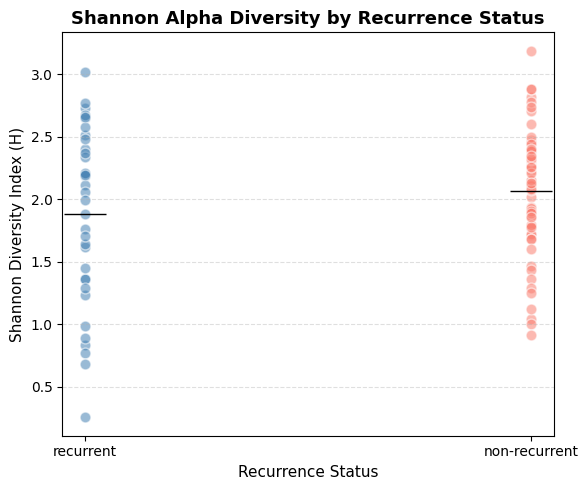

Mean Shannon — recurrent:     1.8823
Mean Shannon — non-recurrent: 2.0693


In [49]:
recurrent_sh = merged_shannon[merged_shannon["recurrence"] == "recurrent"]["shannon_diversity"]
non_recurrent_sh = merged_shannon[merged_shannon["recurrence"] == "non-recurrent"]["shannon_diversity"]

fig, ax = plt.subplots(figsize=(6, 5))
for vals, label, color in [
    (recurrent_sh, "recurrent", "steelblue"),
    (non_recurrent_sh, "non-recurrent", "salmon"),
]:
    ax.scatter([label] * len(vals), vals, alpha=0.55, color=color, edgecolors="white", s=60)
    ax.plot([label], [vals.mean()], marker="_", markersize=30, linewidth=3, color="black")

ax.set_xlabel("Recurrence Status", fontsize=11)
ax.set_ylabel("Shannon Diversity Index (H)", fontsize=11)
ax.set_title("Shannon Alpha Diversity by Recurrence Status", fontsize=13, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("shannon_diversity_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean Shannon — recurrent:     {recurrent_sh.mean():.4f}")
print(f"Mean Shannon — non-recurrent: {non_recurrent_sh.mean():.4f}")

## Random Forest on Delta Shannon Alpha Diversity (Tumor − Normal, per patient)

In [50]:
# Attach Sample Name to each SRR so we can split TN / TT
shannon_meta = shannon_df.join(meta[["Sample Name", "recurrence"]], how="inner")

shannon_norm = {}   # patient_num -> TN shannon value
shannon_tumor = {}  # patient_num -> TT shannon value

for srr, row in shannon_meta.iterrows():
    sample_name = row["Sample Name"]
    patient_num = sample_name.split("-")[0]
    if sample_name.endswith("TN"):
        shannon_norm[patient_num] = row["shannon_diversity"]
    elif sample_name.endswith("TT"):
        shannon_tumor[patient_num] = row["shannon_diversity"]

# Keep only paired patients
paired_patients = sorted(set(shannon_norm) & set(shannon_tumor))

delta_shannon = pd.Series(
    {p: shannon_tumor[p] - shannon_norm[p] for p in paired_patients},
    name="delta_shannon",
)

print(f"Paired patients: {len(paired_patients)}")
print(delta_shannon.describe())

Paired patients: 50
count    50.000000
mean     -0.305594
std       0.656684
min      -2.261176
25%      -0.702156
50%      -0.201443
75%       0.149339
max       1.035128
Name: delta_shannon, dtype: float64


In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# Recurrence label comes from the TN (normal) side, same as the CLR delta RFC
meta_tn = meta[meta["Sample Name"].str.endswith("TN")].copy()
meta_tn.index = meta_tn["Sample Name"].str.split("-").str[0]

delta_shannon_df = delta_shannon.to_frame().join(meta_tn[["recurrence"]], how="inner")

print(f"Samples after merge: {len(delta_shannon_df)}")
print(f"Class distribution:\n{delta_shannon_df['recurrence'].value_counts()}")

X_dsh = delta_shannon_df[["delta_shannon"]].values
y_dsh = delta_shannon_df["recurrence"].values

le_dsh = LabelEncoder()
y_dsh_encoded = le_dsh.fit_transform(y_dsh)
print(f"\nClasses: {le_dsh.classes_}")

X_train_dsh, X_test_dsh, y_train_dsh, y_test_dsh = train_test_split(
    X_dsh, y_dsh_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_dsh_encoded,
)
print(f"\nTrain: {len(X_train_dsh)} samples | Test: {len(X_test_dsh)} samples")

rf_dsh = RandomForestClassifier(
    n_estimators=500,
    max_features=1,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_dsh.fit(X_train_dsh, y_train_dsh)

y_pred_dsh = rf_dsh.predict(X_test_dsh)

print("\n── Classification Report (Delta Shannon Alpha Diversity) ──────────")
print(classification_report(y_test_dsh, y_pred_dsh, target_names=le_dsh.classes_))

Samples after merge: 50
Class distribution:
recurrence
non-recurrent    33
recurrent        17
Name: count, dtype: int64

Classes: ['non-recurrent' 'recurrent']

Train: 40 samples | Test: 10 samples

── Classification Report (Delta Shannon Alpha Diversity) ──────────
               precision    recall  f1-score   support

non-recurrent       0.75      0.86      0.80         7
    recurrent       0.50      0.33      0.40         3

     accuracy                           0.70        10
    macro avg       0.62      0.60      0.60        10
 weighted avg       0.68      0.70      0.68        10



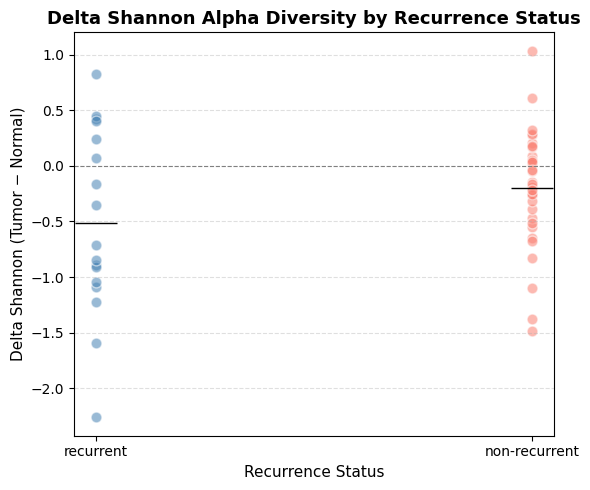

Mean delta Shannon — recurrent:     -0.5100
Mean delta Shannon — non-recurrent: -0.2003


In [52]:
recurrent_dsh = delta_shannon_df[delta_shannon_df["recurrence"] == "recurrent"]["delta_shannon"]
non_recurrent_dsh = delta_shannon_df[delta_shannon_df["recurrence"] == "non-recurrent"]["delta_shannon"]

fig, ax = plt.subplots(figsize=(6, 5))
for vals, label, color in [
    (recurrent_dsh, "recurrent", "steelblue"),
    (non_recurrent_dsh, "non-recurrent", "salmon"),
]:
    ax.scatter([label] * len(vals), vals, alpha=0.55, color=color, edgecolors="white", s=60)
    ax.plot([label], [vals.mean()], marker="_", markersize=30, linewidth=3, color="black")

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Recurrence Status", fontsize=11)
ax.set_ylabel("Delta Shannon (Tumor − Normal)", fontsize=11)
ax.set_title("Delta Shannon Alpha Diversity by Recurrence Status", fontsize=13, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("delta_shannon_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean delta Shannon — recurrent:     {recurrent_dsh.mean():.4f}")
print(f"Mean delta Shannon — non-recurrent: {non_recurrent_dsh.mean():.4f}")